# Laboratorio 8 — MM3014 Teoría de Probabilidades
**Universidad del Valle de Guatemala**  
Departamento de Matemática  
José Carlos Ovando Asencio — Carné: 24701  
Juan Francisco Orozco — Carné: 24647

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros generales
N      = 100        # total de estampas
S      = 7          # estampas por sobre
PRICE  = 9.50       # precio por sobre (Q)
BUDGET = 1000.0     # presupuesto total (Q)
R      = 10_000     # simulaciones
SEED   = 2026

## Etapa 3: Incorporación del presupuesto y costo
### Simulación principal

In [12]:
rng = np.random.default_rng(SEED)

comp_3 = np.zeros(R, dtype=int)
env_3  = np.zeros(R, dtype=int)
dist_3 = np.zeros(R, dtype=int)

for i in range(R):
    coll  = set()
    spent = 0.0
    envs  = 0
    while spent + PRICE <= BUDGET and len(coll) < N:
        coll.update(rng.integers(0, N, size=S))
        spent += PRICE
        envs  += 1
    comp_3[i] = int(len(coll) == N)
    env_3[i]  = envs
    dist_3[i] = int(len(coll))

p_comp    = comp_3.mean()
e_env     = env_3.mean()
fail_mask = comp_3 == 0
e_dist_f  = dist_3[fail_mask].mean() if fail_mask.any() else float(N)

print(f"P(completar álbum con Q{BUDGET:.2f}):           {p_comp:.4f}")
print(f"E[sobres comprados]:                            {e_env:.2f}")
print(f"E[estampas distintas | no completó]:            {e_dist_f:.2f}")
print(f"Simulaciones no exitosas:                       {fail_mask.sum()}")

P(completar álbum con Q1000.00):           0.9436
E[sobres comprados]:                            73.56
E[estampas distintas | no completó]:            98.97
Simulaciones no exitosas:                       564


### Visualización — Diagrama de barras

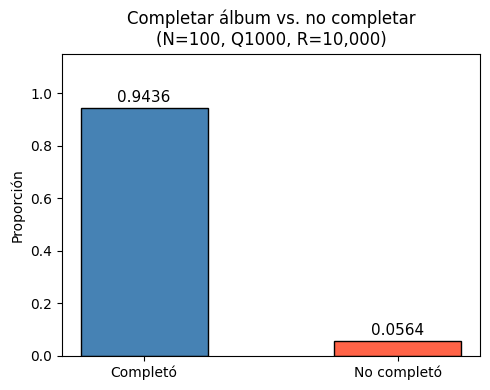

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Completó', 'No completó'], [p_comp, 1 - p_comp],
              color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
            f'{h:.4f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Proporción')
ax.set_ylim(0, 1.15)
ax.set_title('Completar álbum vs. no completar\n(N=100, Q1000, R=10,000)')
plt.tight_layout()
plt.savefig('etapa3_barras.png', dpi=150, bbox_inches='tight')
plt.show()

### Preguntas de análisis

In [14]:
# Pregunta 1
max_env  = int(BUDGET // PRICE)        # 105
total_st = max_env * S                 # 735
min_theo = int(np.ceil(N / S))         # 15
print(f"P1.")
print(f"  Máximo de sobres comprables con Q{BUDGET:.2f}:    {max_env}")
print(f"  Estampas disponibles (con repetidos):           {max_env}x{S} = {total_st}")
print(f"  >= {N} estampas en teoría?                      {'Sí' if total_st >= N else 'No'} ({total_st} >= {N})")
print(f"  Mínimo teórico sin repetidos:                   ceil({N}/{S}) = {min_theo} sobres")

# Pregunta 2 — caja de 104 sobres
BOX, CBOX = 104, 975.0
rng_box = np.random.default_rng(SEED)
comp_box = np.zeros(R, dtype=int)
for i in range(R):
    coll = set()
    for _ in range(BOX):
        coll.update(rng_box.integers(0, N, size=S))
    comp_box[i] = int(len(coll) == N)
p_box = comp_box.mean()

print(f"\nP2.")
print(f"  P(completar, sobres sueltos):  {p_comp:.4f}  ({max_env} sobres, Q{max_env*PRICE:.2f})")
print(f"  P(completar, caja):            {p_box:.4f}  ({BOX} sobres, Q{CBOX:.2f})")
print(f"  Conviene caja? {'Sí' if p_box > p_comp else 'No'} (Delta = {p_box-p_comp:+.4f})")

# Pregunta 3 — estrategia mixta
extra    = int((BUDGET - CBOX) // PRICE)   # 2
n_mix    = BOX + extra                     # 106
cost_mix = CBOX + extra * PRICE
rng_mix  = np.random.default_rng(SEED)
comp_mix = np.zeros(R, dtype=int)
for i in range(R):
    coll = set()
    for _ in range(n_mix):
        coll.update(rng_mix.integers(0, N, size=S))
    comp_mix[i] = int(len(coll) == N)
p_mix = comp_mix.mean()

options   = [('sueltos', p_comp), ('caja sola', p_box), ('mixta', p_mix)]
best_name, best_p = max(options, key=lambda x: x[1])

print(f"\nP3.")
print(f"  Estrategia: {BOX} (caja) + {extra} sueltos = {n_mix} sobres | costo Q{cost_mix:.2f}")
print(f"  Presupuesto sin gastar: Q{BUDGET - cost_mix:.2f}")
print(f"  P(completar, mixta):  {p_mix:.4f}")
print(f"  Sueltos={p_comp:.4f} | Caja={p_box:.4f} | Mixta={p_mix:.4f}")
print(f"  Estrategia óptima dentro de Q{BUDGET:.2f}: {best_name} (P = {best_p:.4f})")

P1.
  Máximo de sobres comprables con Q1000.00:    105
  Estampas disponibles (con repetidos):           105x7 = 735
  >= 100 estampas en teoría?                      Sí (735 >= 100)
  Mínimo teórico sin repetidos:                   ceil(100/7) = 15 sobres

P2.
  P(completar, sobres sueltos):  0.9436  (105 sobres, Q997.50)
  P(completar, caja):            0.9342  (104 sobres, Q975.00)
  Conviene caja? No (Delta = -0.0094)

P3.
  Estrategia: 104 (caja) + 2 sueltos = 106 sobres | costo Q994.00
  Presupuesto sin gastar: Q6.00
  P(completar, mixta):  0.9440
  Sueltos=0.9436 | Caja=0.9342 | Mixta=0.9440
  Estrategia óptima dentro de Q1000.00: mixta (P = 0.9440)


## Etapa 4: Efecto del intercambio de repetidas
### Funciones auxiliares

In [15]:
K_LIST = [1, 2, 5, 10]

def run_until_complete(N, S, K, R, rng):
    """Simula R veces hasta completar el álbum con canje K:1."""
    envs = np.zeros(R, dtype=int)
    for i in range(R):
        counts   = np.zeros(N, dtype=int)
        distinct = 0
        rep      = 0
        e        = 0
        while distinct < N:
            stamps = rng.integers(0, N, size=S)
            e += 1
            for s in stamps:
                if counts[s] == 0:
                    distinct += 1
                else:
                    rep += 1
                counts[s] += 1
            while rep >= K and distinct < N:
                missing = np.where(counts == 0)[0]
                counts[missing[rng.integers(len(missing))]] += 1
                distinct += 1
                rep -= K
        envs[i] = e
    return envs

def run_fixed_M(N, S, K, M, R, rng):
    """Simula R veces con exactamente M sobres y canje K:1. Devuelve P(éxito)."""
    succ = 0
    for _ in range(R):
        counts   = np.zeros(N, dtype=int)
        distinct = 0
        rep      = 0
        for _ in range(M):
            stamps = rng.integers(0, N, size=S)
            for s in stamps:
                if counts[s] == 0:
                    distinct += 1
                else:
                    rep += 1
                counts[s] += 1
            while rep >= K and distinct < N:
                missing = np.where(counts == 0)[0]
                counts[missing[rng.integers(len(missing))]] += 1
                distinct += 1
                rep -= K
        succ += int(distinct == N)
    return succ / R

print("Funciones definidas.")

Funciones definidas.


### Parte A: Simulación hasta completar el álbum

In [16]:
# Referencia sin intercambio
rng_rA = np.random.default_rng(SEED)
ref_envs = np.zeros(R, dtype=int)
for i in range(R):
    coll = set()
    e = 0
    while len(coll) < N:
        coll.update(rng_rA.integers(0, N, size=S))
        e += 1
    ref_envs[i] = e
ref_m, ref_s = ref_envs.mean(), ref_envs.std()
print(f"Sin intercambio:   media={ref_m:.2f}, sd={ref_s:.2f}")

results_A = {}
for K in K_LIST:
    rng_k  = np.random.default_rng(SEED)
    envs_k = run_until_complete(N, S, K, R, rng_k)
    m_k, s_k = envs_k.mean(), envs_k.std()
    red_k    = (ref_m - m_k) / ref_m * 100
    results_A[K] = envs_k
    print(f"K={K:2d}:            media={m_k:.2f}, sd={s_k:.2f}, reducción={red_k:.1f}%")

Sin intercambio:   media=74.43, sd=17.84
K= 1:            media=15.00, sd=0.00, reducción=79.8%
K= 2:            media=20.03, sd=0.54, reducción=73.1%
K= 5:            media=28.56, sd=1.46, reducción=61.6%
K=10:            media=35.89, sd=2.44, reducción=51.8%


### Histogramas superpuestos (Parte A)

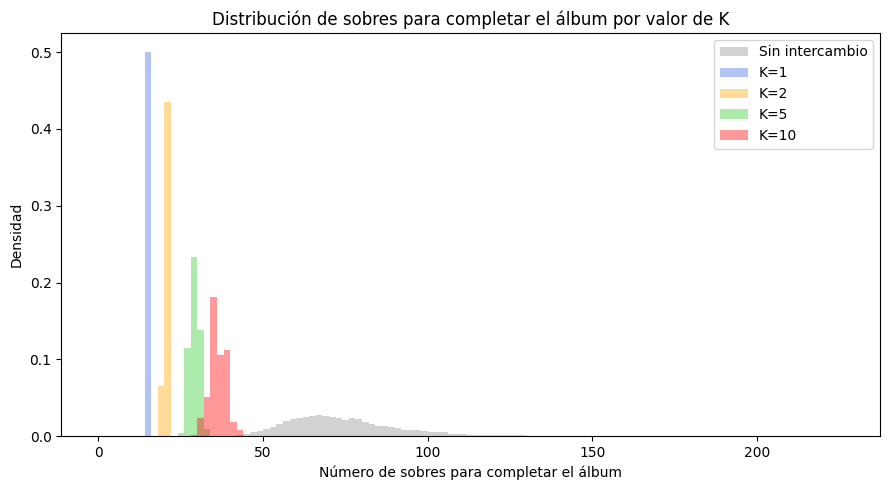

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
bmax = max(ref_envs.max(), max(v.max() for v in results_A.values()))
bins = np.arange(0, bmax + 3, 2)
ax.hist(ref_envs, bins=bins, alpha=0.35, density=True,
        label='Sin intercambio', color='gray')
pal = {1: 'royalblue', 2: 'orange', 5: 'limegreen', 10: 'red'}
for K in K_LIST:
    ax.hist(results_A[K], bins=bins, alpha=0.4, density=True,
            label=f'K={K}', color=pal[K])
ax.set_xlabel('Número de sobres para completar el álbum')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de sobres para completar el álbum por valor de K')
ax.legend()
plt.tight_layout()
plt.savefig('etapa4_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

### Parte B: Probabilidad de éxito en función de M
*(Esta celda puede tardar varios minutos)*

In [ ]:
M_LIST = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

# Referencia sin intercambio
print("Calculando referencia...")
ref_probs_B = []
for M in M_LIST:
    rng_m = np.random.default_rng(SEED)
    succ = 0
    for _ in range(R):
        coll = set()
        for _ in range(M):
            coll.update(rng_m.integers(0, N, size=S))
        succ += int(len(coll) == N)
    ref_probs_B.append(succ / R)

# Con intercambio para cada K
probs_B = {}
for K in K_LIST:
    print(f"Calculando K={K}...")
    probs_k = []
    for M in M_LIST:
        rng_km = np.random.default_rng(SEED)
        probs_k.append(run_fixed_M(N, S, K, M, R, rng_km))
    probs_B[K] = probs_k

# Tabla de resultados
print(f"\n{'M':>4}  {'Sin K':>7}", end='')
for K in K_LIST:
    print(f"  {'K='+str(K):>7}", end='')
print()
print("-" * 47)
for j, M in enumerate(M_LIST):
    print(f"{M:>4}  {ref_probs_B[j]:>7.4f}", end='')
    for K in K_LIST:
        print(f"  {probs_B[K][j]:>7.4f}", end='')
    print()

Calculando referencia...
Calculando K=1...
Calculando K=2...


### Gráfica de líneas P(éxito) vs M

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(M_LIST, ref_probs_B, 'k--o', label='Sin intercambio', linewidth=2, markersize=6)
line_info = {1: ('royalblue', '-o'), 2: ('orange', '-s'),
             5: ('limegreen', '-^'), 10: ('red', '-D')}
for K in K_LIST:
    c, sty = line_info[K]
    ax.plot(M_LIST, probs_B[K], sty, color=c, label=f'K={K}', linewidth=2, markersize=6)
ax.set_xlabel('Número de sobres (M)')
ax.set_ylabel('P(completar álbum)')
ax.set_ylim(0, 1.05)
ax.set_title('Probabilidad de completar el álbum vs. número de sobres M')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('etapa4_lineas.png', dpi=150, bbox_inches='tight')
plt.show()

### Preguntas de análisis (Etapa 4)

In [ ]:
def m_threshold(M_list, probs, pct):
    for m, p in zip(M_list, probs):
        if p >= pct:
            return m
    return ">70"

# Umbrales
print("Sobres mínimos para P(éxito) >= 50%, 75%, 90%:")
print(f"{'Caso':>12} | {'M(50%)':>8} | {'M(75%)':>8} | {'M(90%)':>8}")
print("-" * 50)
casos = [("Sin canje", ref_probs_B)] + [(f"K={K}", probs_B[K]) for K in K_LIST]
for name, plist in casos:
    print(f"{name:>12} | {str(m_threshold(M_LIST,plist,0.50)):>8} | "
          f"{str(m_threshold(M_LIST,plist,0.75)):>8} | "
          f"{str(m_threshold(M_LIST,plist,0.90)):>8}")

# P1
ref_mean_A = ref_envs.mean()
print("\nP1. Media de sobres y reducción por K:")
for K in K_LIST:
    m_k = results_A[K].mean()
    print(f"  K={K:2d}: media={m_k:.2f}, ahorro={ref_mean_A-m_k:.2f} sobres "
          f"({(ref_mean_A-m_k)/ref_mean_A*100:.1f}%)")
print("  Relación NO lineal: mejora marginal decreciente al bajar K.")
print(f"  Con K=1 el álbum es determinista: media={results_A[1].mean():.2f}, sd={results_A[1].std():.2f}")

# P2
m_k2 = results_A[2].mean()
denv = ref_mean_A - m_k2
print(f"\nP2. K=2 ahorra {denv:.2f} sobres ~ Q{denv*PRICE:.2f}")

# P3
i45 = M_LIST.index(45)
print(f"\nP3. P(éxito) con M=45:")
print(f"  Sin canje: {ref_probs_B[i45]:.4f}")
for K in K_LIST:
    print(f"  K={K:2d}: {probs_B[K][i45]:.4f}")

# P4
deltas = {K: ref_mean_A - results_A[K].mean() for K in K_LIST}
sk = sorted(K_LIST, reverse=True)
print("\nP4. Mejora adicional al reducir K:")
for i in range(len(sk)-1):
    print(f"  K={sk[i]}->K={sk[i+1]}: +{deltas[sk[i+1]]-deltas[sk[i]]:.2f} sobres")
print("  Rendimiento decreciente; K=2 ya aprovecha casi toda la ventaja del canje.")

# P5
cps = PRICE / S
print(f"\nP5. Costo por estampa via canje (base: Q{PRICE}/{S} = Q{cps:.4f}/estampa):")
for K in K_LIST:
    print(f"  K={K:2d}: Q{K*cps:.4f} por estampa nueva")
print(f"  K=1 es el más rentable: Q{cps:.4f} por estampa.")